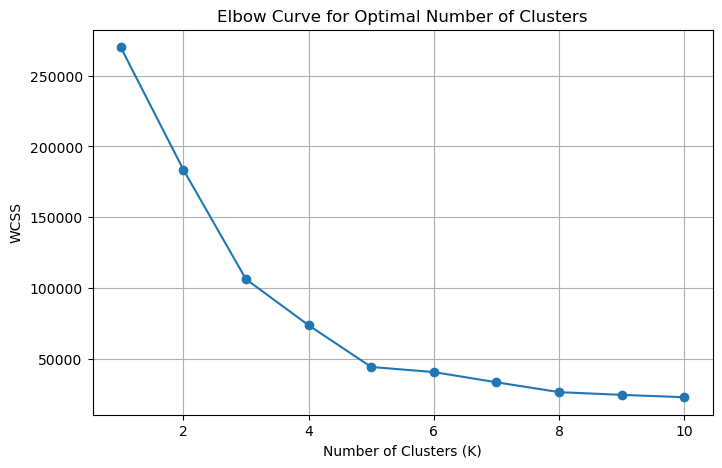

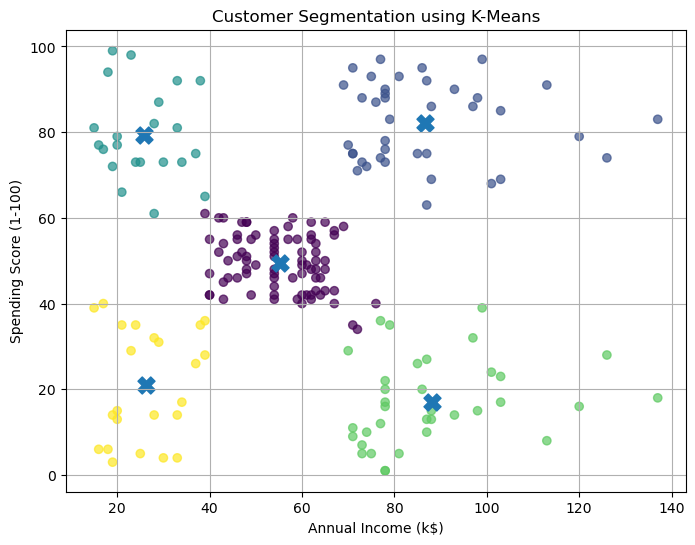


Cluster Distribution:
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Sample Data with Cluster Labels:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  

✅ Task 02 Completed Successfully


In [1]:
# ==========================================
# TASK 02: Customer Segmentation using K-Means
# ==========================================

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Imports
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------
customer_data = pd.read_csv("Mall_Customers.csv")

# ------------------------------------------
# 2. Select Relevant Features
# ------------------------------------------
# Using Annual Income and Spending Score
features = customer_data[["Annual Income (k$)", "Spending Score (1-100)"]]

# ------------------------------------------
# 3. Elbow Method to Find Optimal Clusters
# ------------------------------------------
wcss_values = []

for k in range(1, 11):
    kmeans_model = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans_model.fit(features)
    wcss_values.append(kmeans_model.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(range(1, 11), wcss_values, marker='o')

plt.title("Elbow Curve for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid()
plt.show()

# ------------------------------------------
# 4. Train Final K-Means Model
# ------------------------------------------
# Based on elbow curve, choose K = 5
kmeans_final = KMeans(n_clusters=5, init="k-means++", random_state=42)
cluster_labels = kmeans_final.fit_predict(features)

# ------------------------------------------
# 5. Visualize Customer Segments
# ------------------------------------------
plt.figure(figsize=(8,6))

plt.scatter(
    features.iloc[:, 0],
    features.iloc[:, 1],
    c=cluster_labels,
    alpha=0.7
)

# Plot cluster centroids
centroids = kmeans_final.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=150,
    marker='X'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.grid()
plt.show()

# ------------------------------------------
# 6. Add Cluster Labels to Dataset
# ------------------------------------------
customer_data["Cluster"] = cluster_labels

# ------------------------------------------
# 7. Show Cluster Insights
# ------------------------------------------
print("\nCluster Distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

print("\nSample Data with Cluster Labels:")
print(customer_data.head())

print("\n✅ Task 02 Completed Successfully")